# Proyecto: Redes Neuronales Bayesianas y Aproximación Variacional

## Objetivo general

El objetivo de este proyecto es construir y analizar redes neuronales bayesianas utilizando distintos enfoques de inferencia probabilística.

Los estudiantes deberán implementar y comparar:

- Redes Neuronales Bayesianas mediante MCMC,
- Inferencia Variacional Bayesiana,
- Redes Bayesianas Convolucionales.

El proyecto busca integrar:

- deep learning,
- inferencia bayesiana,
- incertidumbre predictiva,
- aproximación variacional,
- métodos Monte Carlo,
- y aprendizaje probabilístico.

---

# Notación

- $x_i$ representa una observación de entrada.
- $y_i$ representa la clase observada.
- $W$ representa matrices de pesos.
- $b$ representa vectores de sesgos.
- $\theta$ representa todos los parámetros de la red.
- $n$ es el número de observaciones.
- $p$ es el número de variables de entrada.
- $K$ es el número de clases.

---

# 1. Redes neuronales clásicas

Una red neuronal estándar consiste en composiciones de transformaciones lineales y funciones no lineales:

$$
h^{(1)}
=
\phi(XW_1+b_1)
$$

$$
h^{(2)}
=
\phi(h^{(1)}W_2+b_2)
$$

$$
z
=
h^{(L)}W_L+b_L
$$

donde:

- $\phi$ representa funciones de activación,
- $z$ representa los logits finales.

---

# 2. Clasificación multiclase

Las probabilidades de clase se obtienen mediante softmax:

$$
p(y_i=k \mid x_i)
=
\frac{\exp(z_{ik})}
{\sum_{j=1}^{K}\exp(z_{ij})}
$$

y:

$$
y_i
\sim
\text{Categorical}(p_i)
$$

---

# 3. Redes Neuronales Bayesianas

En una red neuronal bayesiana los pesos no son valores fijos.

En cambio:

$$
W_{ij}
\sim
p(W_{ij})
$$

y:

$$
b_j
\sim
p(b_j)
$$

Esto permite modelar incertidumbre sobre los parámetros de la red.

---

# 4. Priors Bayesianos

En este proyecto se utilizan priors Gaussianos:

$$
W_{ij}
\sim
\mathcal{N}(0,1)
$$

$$
b_j
\sim
\mathcal{N}(0,1)
$$

Estos priors inducen regularización probabilística sobre la red neuronal.

---

# 5. Inferencia mediante MCMC

El primer enfoque utiliza:

- Hamiltonian Monte Carlo (HMC),
- No-U-Turn Sampler (NUTS).

El objetivo es aproximar:

$$
p(\theta \mid X,y)
$$

donde $\theta$ representa todos los pesos y sesgos de la red.

---

# 6. Ventajas y limitaciones de MCMC

---

## Ventajas

- inferencia posterior completa,
- cuantificación rigurosa de incertidumbre,
- aproximación exacta asintóticamente.

---

## Desventajas

- alto costo computacional,
- escalabilidad limitada,
- entrenamiento lento en redes profundas.

---

# 7. Inferencia Variacional Bayesiana

El segundo enfoque utiliza inferencia variacional.

La idea principal consiste en aproximar:

$$
p(\theta \mid X,y)
$$

mediante una distribución variacional:

$$
q_\phi(\theta)
$$

más sencilla y parametrizada.

---

# 8. Aproximación variacional

Cada peso se modela mediante:

$$
W_{ij}
\sim
\mathcal{N}(\mu_{ij},\sigma_{ij}^2)
$$

donde:

- $\mu_{ij}$ es la media variacional,
- $\sigma_{ij}$ controla incertidumbre.

Los parámetros variacionales se optimizan mediante descenso por gradiente.

---

# 9. Reparameterization Trick

Para permitir backpropagation se utiliza:

$$
W
=
\mu
+
\sigma\varepsilon
$$

con:

$$
\varepsilon
\sim
\mathcal{N}(0,1)
$$

Esto permite derivar respecto a:

- $\mu$,
- $\sigma$.

---

# 10. Evidence Lower Bound (ELBO)

La inferencia variacional maximiza:

$$
\text{ELBO}
=
\mathbb{E}_{q_\phi}
[\log p(y \mid X,\theta)]
-
\text{KL}(q_\phi(\theta)\|p(\theta))
$$

Equivalentemente, se minimiza:

$$
\mathcal{L}
=
\text{NLL}
+
\beta \cdot \text{KL}
$$

donde:

- NLL corresponde al error predictivo,
- KL penaliza desviación respecto al prior,
- $\beta$ controla regularización.

---

# 11. Monte Carlo Sampling

Durante entrenamiento se generan múltiples muestras de pesos:

$$
\theta^{(1)},\dots,\theta^{(S)}
$$

para aproximar expectativas mediante Monte Carlo.

Esto permite:

- cuantificar incertidumbre,
- obtener distribuciones predictivas,
- analizar estabilidad del modelo.

---

# 12. Early Stopping

El entrenamiento utiliza early stopping:

- monitoreando pérdida de validación,
- guardando el mejor modelo,
- deteniendo entrenamiento cuando no exista mejora significativa.

Esto ayuda a:

- evitar sobreajuste,
- mejorar generalización,
- reducir tiempo computacional.

---

# 13. Redes Bayesianas Convolucionales

Como extensión opcional se propone utilizar capas convolucionales bayesianas.

En este caso:

- los filtros convolucionales también poseen distribuciones posteriores,
- la incertidumbre se propaga espacialmente.

---

# 14. Convoluciones Bayesianas

Los filtros convolucionales satisfacen:

$$
W_{ijkl}
\sim
\mathcal{N}(\mu_{ijkl},\sigma_{ijkl}^2)
$$

permitiendo:

- modelar incertidumbre en visión computacional,
- cuantificar confianza en imágenes,
- generar predicciones probabilísticas.

---

# 15. Comparación entre enfoques

Los estudiantes deberán comparar:

---

## MCMC

Ventajas:

- inferencia posterior más precisa,
- mejor cuantificación de incertidumbre.

Desventajas:

- extremadamente costoso computacionalmente.

---

## Inferencia Variacional

Ventajas:

- escalabilidad,
- entrenamiento eficiente,
- compatible con deep learning moderno.

Desventajas:

- aproximación sesgada,
- depende de la familia variacional elegida.

---

# 16. Métricas de evaluación

Las métricas sugeridas incluyen:

---

## Negative Log-Likelihood (NLL)

$$
\text{NLL}
=
-\log p(y_{\text{valid}} \mid X_{\text{valid}})
$$

---

## Accuracy

$$
\text{Accuracy}
=
\frac{1}{n}
\sum_{i=1}^{n}
\mathbb{I}(y_i=\hat y_i)
$$

---

## Incertidumbre predictiva

Los estudiantes deberán analizar:

- distribuciones predictivas,
- estabilidad de predicciones,
- variabilidad entre muestras posteriores.

---

# 17. Visualización y análisis posterior

Los estudiantes deberán analizar:

- curvas de entrenamiento,
- curvas de validación,
- distribuciones posteriores,
- muestras predictivas,
- incertidumbre predictiva,
- estabilidad de accuracy.

También deberán visualizar:

- densidades posteriores,
- histogramas de accuracy,
- comportamiento de ELBO,
- evolución del entrenamiento.

---

# 18. Objetivos específicos del proyecto

Los estudiantes deberán:

1. Seleccionar un dataset real de clasificación.
2. Construir una red neuronal bayesiana.
3. Implementar inferencia mediante MCMC.
4. Implementar inferencia variacional.
5. Comparar ambos enfoques.
6. Analizar incertidumbre predictiva.
7. Implementar early stopping.
8. Evaluar desempeño predictivo.
9. Explorar capas convolucionales bayesianas opcionalmente.
10. Elaborar conclusiones estadísticas y computacionales.

---

# 19. Entregables sugeridos

El proyecto deberá incluir:

- notebook reproducible,
- explicación teórica,
- análisis exploratorio,
- implementación de modelos,
- métricas de evaluación,
- visualizaciones posteriores,
- curvas de entrenamiento,
- análisis de incertidumbre,
- conclusiones.

In [1]:
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood
import jax.random as random
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, ParameterSampler, KFold
from sklearn.datasets import load_digits
from scipy.stats import distributions as scdist
import numpyro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from tqdm import tqdm


numpyro.set_host_device_count(3)
plt.style.use("default")

# Dataset

In [2]:
X, y = load_digits(return_X_y=True)
X = X/X.max()
X = jnp.asarray(X)
y = jnp.asarray(y)
X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Model

In [6]:
def bnn_model_mcmc(X, y=None, hidden_dim=120, k=10):

    n, p = X.shape

    W1 = numpyro.sample(
            "W1",
            dist.Normal(0.0, 1.0).expand([p, hidden_dim]).to_event(2)
        )

    b1 = numpyro.sample(
            "b1",
            dist.Normal(0.0, 1.0).expand([hidden_dim]).to_event(1)
        )

    W2 = numpyro.sample(
            "W2",
            dist.Normal(0.0, 1.0).expand([hidden_dim, hidden_dim]).to_event(2)
        )


    b2 = numpyro.sample(
            "b2",
            dist.Normal(0.0, 1.0).expand([hidden_dim]).to_event(1)
    )

    W3 = numpyro.sample(
            "W3",
            dist.Normal(0.0, 1.0).expand([hidden_dim, k]).to_event(2)
        )


    b3 = numpyro.sample(
            "b3",
            dist.Normal(0.0, 1.0).expand([k]).to_event(1)
    )


    with numpyro.plate("data", n):

            a1 = jnp.tanh(jnp.dot(X, W1) + b1)

            a2 = jnp.tanh(jnp.dot(a1, W2) + b2)

            z = jnp.tanh(jnp.dot(a2, W3) + b3)

            numpyro.sample("y", dist.Categorical(logits=z), obs=y)





# MCMC

In [7]:
burn_in = 500
num_samples = 1000
num_chains = 3
chain_method = "parallel"

seed = 18081997

In [8]:
rng_key = random.PRNGKey(seed)

kernel = NUTS(bnn_model_mcmc)

mcmc = MCMC(kernel,
            num_samples=num_samples,
            num_chains=num_chains,
            num_warmup=burn_in,
            chain_method=chain_method,
            progress_bar=True)

mcmc.run(rng_key, X_train, y_train, hidden_dim=10, k=10)

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

In [9]:
samples = mcmc.get_samples()

W1_samples = samples["W1"]
W2_samples = samples["W2"]
W3_samples = samples["W3"]
b1_samples = samples["b1"]
b2_samples = samples["b2"]
b3_samples = samples["b3"]

In [10]:
x = jnp.tanh(jnp.matmul(X_test, W1_samples) + b1_samples[:, None , :])
x = jnp.tanh(jnp.matmul(x, W2_samples) + b2_samples[:, None , :])
x = jax.nn.softmax(jnp.tanh(jnp.matmul(x, W3_samples) + b3_samples[:, None , :]), axis=-1)
y_pred_samples = jnp.argmax(x, axis=-1)

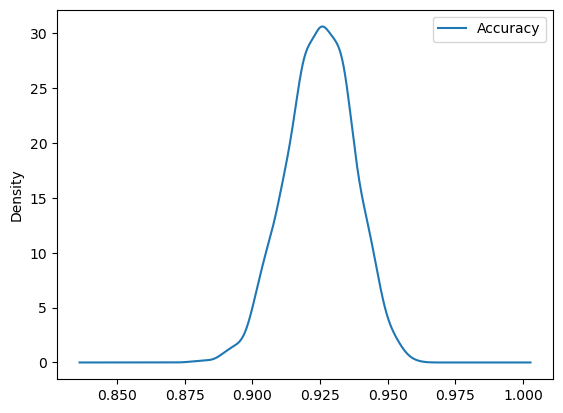

In [11]:
accuracy_samples = (y_test[None, :] ==  y_pred_samples).mean(axis=-1)
pd.DataFrame(accuracy_samples, columns=["Accuracy"]).plot.kde()
plt.show()

In [12]:
alpha = 5
jnp.percentile(accuracy_samples, jnp.array([5/2, 100-5/2]))

Array([0.90000004, 0.94722223], dtype=float32)

# **Variational Inference**

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## **Multilayer Perceptron**

In [15]:
# Capa bayesiana
class BayesianLinear(nn.Module):

    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.prior_sigma = prior_sigma

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_rho = nn.Parameter(torch.empty(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_rho = nn.Parameter(torch.empty(out_features))

        self.reset_parameters()

    def reset_parameters(self):

        nn.init.kaiming_normal_(self.weight_mu)
        self.weight_rho.data.fill_(-5)
        nn.init.zeros_(self.bias_mu)
        self.bias_rho.data.fill_(-5)

    def forward(self, x, n_samples=1):


        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        if x.dim() == 2:
            x = x.unsqueeze(0).expand(n_samples, *x.shape)

        S = x.size(0)

        eps_w = torch.randn(S, *self.weight_mu.shape, device=x.device)
        eps_b = torch.randn(S, *self.bias_mu.shape, device=x.device)

        weight = self.weight_mu + sigma_w * eps_w
        bias = self.bias_mu + sigma_b * eps_b

        out = torch.einsum("sbi,soi->sbo", x, weight) + bias.unsqueeze(1)

        return out

    def kl(self, mu, rho):

        sigma = torch.log1p(torch.exp(rho))

        return (
                torch.log(self.prior_sigma / sigma)
                + (sigma**2 + mu**2) / (2 * self.prior_sigma**2)
                - 0.5
            ).sum()

    def kl_loss(self):

        return self.kl(self.weight_mu, self.weight_rho) + self.kl(self.bias_mu, self.bias_rho)



In [16]:
class BayesianNN(nn.Module):

    def __init__(self, prior_sigma=1.0):

        super().__init__()
        self.fc1 = BayesianLinear(64, 128, prior_sigma)
        self.fc2 = BayesianLinear(128, 128, prior_sigma)
        self.fc3 = BayesianLinear(128, 10, prior_sigma)

    def forward(self, x, n_samples=1):

        x = torch.relu(self.fc1(x, n_samples))
        x = torch.relu(self.fc2(x, n_samples))
        x = self.fc3(x, n_samples)

        return x

    def kl_loss(self):
        return self.fc1.kl_loss() + self.fc2.kl_loss() + self.fc3.kl_loss()

In [17]:
def elbo_loss(model, x, y, n_samples=1, beta=1e-5):

    logits = model(x, n_samples=n_samples)

    S, B, C = logits.shape

    y_expand = y.unsqueeze(0).expand(S, B)

    logits_flat = logits.reshape(S * B, C)
    y_flat = y_expand.reshape(S * B)

    nll = F.cross_entropy(logits_flat, y_flat, reduction='mean')

    kl = model.kl_loss()

    loss = nll + beta * kl

    return loss

In [18]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=128,
    shuffle=True
)


In [19]:
model = BayesianNN(prior_sigma=1.0).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 100

loss_history = []
val_loss_history = []

best_loss = float("inf")
best_state = None

patience_counter = 0
tol = 1e-5
patience = 4

beta = 1e-5
elbo_samples = 10

torch.random.manual_seed(18081997)

progress_bar = tqdm(range(num_epochs), desc="Training")

for epoch in progress_bar:

    model.train()

    epoch_loss = 0.0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        loss = elbo_loss(model, xb, yb,n_samples=elbo_samples, beta=beta)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    loss_history.append(epoch_loss)

    model.eval()

    with torch.no_grad():

        val_loss = elbo_loss(model, X_test, y_test, n_samples=elbo_samples,beta=beta).item()

    val_loss_history.append(val_loss)

    if val_loss < best_loss - tol:

        best_loss = val_loss

        best_state = copy.deepcopy(model.state_dict())

        patience_counter = 0

    else:

        patience_counter += 1

    progress_bar.set_postfix({
        "train_loss": f"{epoch_loss:.4f}",
        "val_loss": f"{val_loss:.4f}"
    })

    if patience_counter >= patience:

        print(f"Early stopping at epoch {epoch}")

        break

# cargar mejor modelo AL FINAL
if best_state is not None:

    model.load_state_dict(best_state)

progress_bar.close()

Training:  53%|█████▎    | 53/100 [00:09<00:08,  5.73it/s, train_loss=0.2443, val_loss=0.4265]

Early stopping at epoch 53


In [20]:
def sample_accuracies(model, X_test, y_test, n_samples=200):

    model.eval()

    X_test = X_test.to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        logits = model(X_test, n_samples=n_samples)  # (S, N, C)
        preds = logits.argmax(dim=2)

        correct = (preds == y_test.unsqueeze(0))
        accs = correct.float().mean(dim=1)

    return accs.cpu().numpy()


acc_samples = sample_accuracies(model, X_test, y_test, 200)

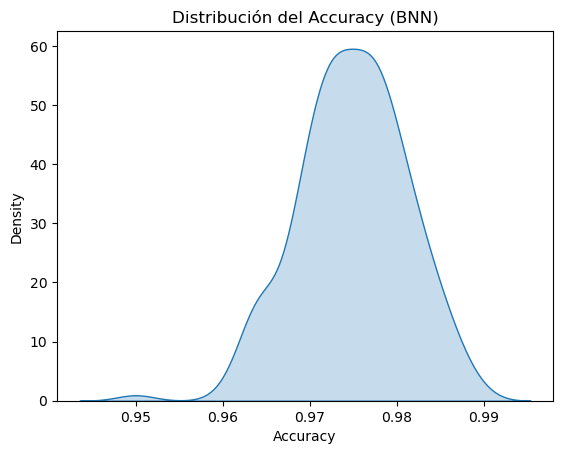

Mean: 0.97486115
Std: 0.006178608
Percentiles: [0.96388888 0.98611116]


In [21]:
sns.kdeplot(acc_samples, fill=True)
plt.xlabel("Accuracy")
plt.title("Distribución del Accuracy (BNN)")
plt.show()


# =========================
# 10. Estadísticas
# =========================
print("Mean:", np.mean(acc_samples))
print("Std:", np.std(acc_samples))
print("Percentiles:", np.percentile(acc_samples, [2.5, 97.5]))

## **Convolutional Neural Network**

In [22]:
class BayesianConv2d(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, prior_sigma=1.0):

        super().__init__()

        self.stride = stride
        self.padding = padding
        self.prior_sigma = prior_sigma

        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)

        # parámetros variacionales
        self.weight_mu = nn.Parameter(
            torch.empty(out_channels, in_channels, *kernel_size)
        )
        self.weight_rho = nn.Parameter(
            torch.empty(out_channels, in_channels, *kernel_size)
        )

        self.bias_mu = nn.Parameter(torch.empty(out_channels))
        self.bias_rho = nn.Parameter(torch.empty(out_channels))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_normal_(self.weight_mu)
        self.weight_rho.data.fill_(-5)

        nn.init.zeros_(self.bias_mu)
        self.bias_rho.data.fill_(-5)

    def forward(self, x, n_samples=1):
        # x: (B, C, H, W)

        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        outputs = []

        for _ in range(n_samples):
            eps_w = torch.randn_like(self.weight_mu)
            eps_b = torch.randn_like(self.bias_mu)

            weight = self.weight_mu + sigma_w * eps_w
            bias = self.bias_mu + sigma_b * eps_b

            out = F.conv2d(
                x,
                weight,
                bias,
                stride=self.stride,
                padding=self.padding
            )

            outputs.append(out)

        return torch.stack(outputs) # (S, B, C, H, W)

    def kl(self, mu, rho):
            sigma = torch.log1p(torch.exp(rho))
            return (
                torch.log(self.prior_sigma / sigma)
                + (sigma**2 + mu**2) / (2 * self.prior_sigma**2)
                - 0.5
            ).sum()

    def kl_loss(self):

        return self.kl(self.weight_mu, self.weight_rho) + self.kl(self.bias_mu, self.bias_rho)

In [23]:
class BayesianCNN(nn.Module):
    def __init__(self, prior_sigma=1.0):
        super().__init__()

        self.conv1 = BayesianConv2d(1, 16, 3, padding=1, prior_sigma=prior_sigma)
        self.conv2 = BayesianConv2d(16, 32, 3, padding=1, prior_sigma=prior_sigma)

        self.fc1 = BayesianLinear(32 * 2 * 2, 64, prior_sigma)
        self.fc2 = BayesianLinear(64, 10, prior_sigma)

        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x, n_samples=1):
        B = x.size(0)
        x = x.view(B, 1, 8, 8)

        # -------- Conv1 --------
        x = self.conv1(x, n_samples)      # (S, B, 16, 8, 8)
        x = torch.relu(x)

        S, B, C, H, W = x.shape
        x = x.view(S * B, C, H, W)
        x = self.pool(x)
        x = x.view(S, B, C, H//2, W//2)   # (S, B, 16, 4, 4)

        # -------- Conv2 --------
        x = x.view(S * B, 16, 4, 4)
        x = self.conv2(x, n_samples=1)    # (1, S*B, 32, 4, 4)
        x = torch.relu(x)

        # quitar dimensión extra de samples
        x = x.squeeze(0)                  # (S*B, 32, 4, 4)

        x = self.pool(x)                  # (S*B, 32, 2, 2)

        # -------- Flatten --------
        x = x.view(S, B, -1)              # (S, B, 32*2*2)

        # -------- FC --------
        x = torch.relu(self.fc1(x, n_samples))
        x = self.fc2(x, n_samples)

        return x

    def kl_loss(self):
        return (
            self.conv1.kl_loss() +
            self.conv2.kl_loss() +
            self.fc1.kl_loss() +
            self.fc2.kl_loss()
        )

In [28]:
model = BayesianCNN(prior_sigma=1.0).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 100

loss_history = []
val_loss_history = []

best_loss = float("inf")
best_state = None

patience_counter = 0
tol = 1e-5
patience = 4

beta = 1e-5
elbo_samples = 10

torch.random.manual_seed(18081997)

progress_bar = tqdm(range(num_epochs), desc="Training")

for epoch in progress_bar:

    model.train()

    epoch_loss = 0.0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        loss = elbo_loss(model, xb, yb,n_samples=elbo_samples, beta=beta)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    loss_history.append(epoch_loss)

    model.eval()

    with torch.no_grad():

        val_loss = elbo_loss(model, X_test, y_test, n_samples=elbo_samples,beta=beta).item()

    val_loss_history.append(val_loss)

    if val_loss < best_loss - tol:

        best_loss = val_loss

        best_state = copy.deepcopy(model.state_dict())

        patience_counter = 0

    else:

        patience_counter += 1

    progress_bar.set_postfix({
        "train_loss": f"{epoch_loss:.4f}",
        "val_loss": f"{val_loss:.4f}"
    })

    if patience_counter >= patience:

        print(f"Early stopping at epoch {epoch}")

        break

# cargar mejor modelo AL FINAL
if best_state is not None:

    model.load_state_dict(best_state)

progress_bar.close()

Training:  54%|█████▍    | 54/100 [00:14<00:12,  3.65it/s, train_loss=0.2055, val_loss=0.2631]

Early stopping at epoch 54


In [29]:
acc_samples = sample_accuracies(model, X_test, y_test, n_samples=1000)

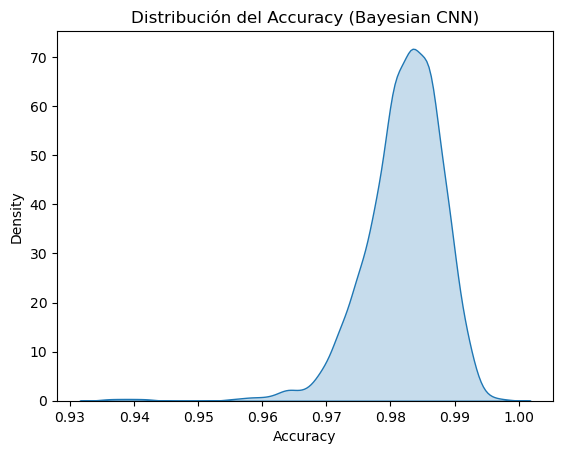

In [30]:
sns.kdeplot(acc_samples, fill=True)
plt.xlabel("Accuracy")
plt.title("Distribución del Accuracy (Bayesian CNN)")
plt.show()

In [31]:
print("Mean:", np.mean(acc_samples))
print("Std:", np.std(acc_samples))
print("Percentiles:", np.percentile(acc_samples, [2.5, 97.5]))

Mean: 0.9820111
Std: 0.0061359536
Percentiles: [0.96944445 0.99166667]
